Assignment - 02
Question 1: Text Analysis Using Bag of
Words and Distance Metrics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
with open("polDoc1.txt", "r") as file:
    polDoc1 = file.read()
with open("polDoc2.txt", "r") as file:
    polDoc2 = file.read()
with open("polDoc3.txt", "r",encoding ='utf-8') as file:
    polDoc3 = file.read()
with open("sciDoc1.txt", "r",encoding ='utf-8') as file:
    SciDoc1 = file.read()
with open("sciDoc2.txt", "r",encoding ='utf-8') as file:
    SciDoc2 = file.read()
with open("sciDoc3.txt", "r",encoding ='utf-8') as file:
    SciDoc3 = file.read()
with open("SDoc1.txt", "r",encoding ='utf-8') as file:
    SDoc1 = file.read()
with open("SDoc2.txt", "r",encoding ='utf-8') as file:
    SDoc2 = file.read()
with open("SDoc3.txt", "r",encoding ='utf-8') as file:
    SDoc3 = file.read()
# Sample Documents: Replace these with your actual document texts
# Each string in the list is one full document.
documents = [
    polDoc1,# Politics
    polDoc2,        # Politics
      polDoc3,       # Politics
        SciDoc1, # Science
       SciDoc2, # Science
       SciDoc3,  # Science
        SDoc1,# Sports
     SDoc2,         # Sports
       SDoc3  # Sports
]
# Bag of Words Preparation
def tokenize(text):
    text = text.lower()
    for char in '-.,\n':
        text = text.replace(char, ' ')
    tokens = [word.strip() for word in text.split() if word.strip() != ""]
    return tokens

# Build vocabulary and term-doc matrix
vocabulary = set()
tokenized_docs = []
for doc in documents:
    tokens = tokenize(doc)
    tokenized_docs.append(tokens)
    vocabulary.update(tokens)
vocabulary = sorted(list(vocabulary))
vocab_index = {word: idx for idx, word in enumerate(vocabulary)}

def build_term_doc_matrix(tokenized_docs, vocab_index):
    matrix = np.zeros((len(tokenized_docs), len(vocab_index)), dtype=int)
    for i, tokens in enumerate(tokenized_docs):
        for word in tokens:
            if word in vocab_index:
                matrix[i][vocab_index[word]] += 1
    return matrix

term_doc_matrix = build_term_doc_matrix(tokenized_docs, vocab_index)
print("Term-Document Matrix:")
print(term_doc_matrix)

Term-Document Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 1 9]
 [1 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


HeatMap Function

In [2]:
def plot_heatmap(matrix, title):
    plt.figure(figsize=(9, 7))
    im = plt.imshow(matrix, interpolation='nearest', cmap='plasma')
    plt.colorbar(im)
    plt.title(title)
    plt.xlabel('Document Index')
    plt.ylabel('Document Index')
    n = matrix.shape[0]
    plt.xticks(np.arange(n), np.arange(1, n+1))
    plt.yticks(np.arange(n), np.arange(1, n+1))

    # Annotate each cell with its value
    for i in range(n):
        for j in range(n):
            value = matrix[i, j]
            plt.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > matrix.max()/2 else "black")
    plt.show()

Jaccard Distance

Jaccard Distance Matrix:
[[0.         0.91738382 0.89823009 0.9        0.92153285 0.91679749
  0.90500642 0.90607735 0.91099476]
 [0.91738382 0.         0.88734835 0.91595197 0.91517857 0.92066421
  0.9127907  0.91469194 0.91004498]
 [0.89823009 0.88734835 0.         0.91618497 0.91949911 0.91679507
  0.91069182 0.9047619  0.92219388]
 [0.9        0.91595197 0.91618497 0.         0.88135593 0.86019737
  0.88396349 0.90495868 0.89986825]
 [0.92153285 0.91517857 0.91949911 0.88135593 0.         0.89494949
  0.90262751 0.8962585  0.925117  ]
 [0.91679749 0.92066421 0.91679507 0.86019737 0.89494949 0.
  0.90379404 0.90161527 0.90555556]
 [0.90500642 0.9127907  0.91069182 0.88396349 0.90262751 0.90379404
  0.         0.86832298 0.85697115]
 [0.90607735 0.91469194 0.9047619  0.90495868 0.8962585  0.90161527
  0.86832298 0.         0.88471178]
 [0.91099476 0.91004498 0.92219388 0.89986825 0.925117   0.90555556
  0.85697115 0.88471178 0.        ]]


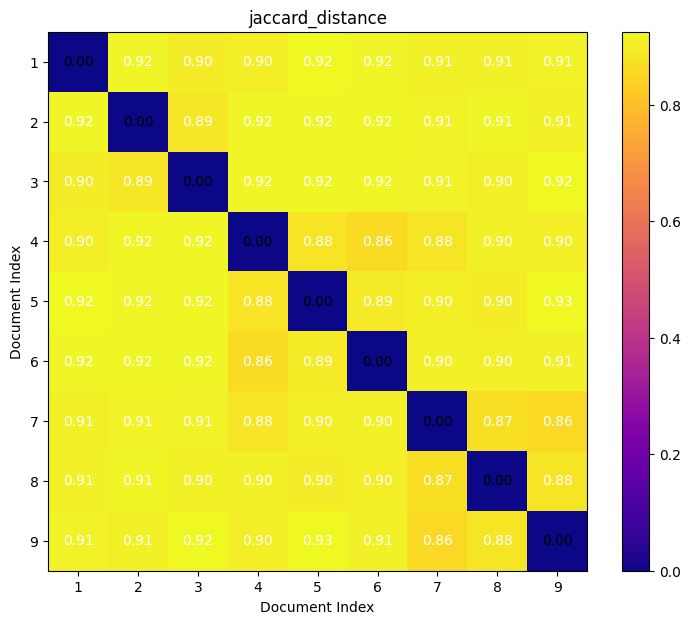

Document 1: Politics
Document 2: Politics
Document 3: Politics
Document 4: Science
Document 5: Science
Document 6: Science
Document 7: Sports
Document 8: Sports
Document 9: Sports


In [3]:
# 1. Jaccard Distance
def jaccard_distance(doc1, doc2):
    set1 = set(doc1)
    set2 = set(doc2)
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    if len(union) == 0:
        return 1.0
    return 1 - float(len(intersection)) / len(union)

jaccard_matrix = np.zeros((len(documents), len(documents)))
for i in range(len(documents)):
    for j in range(len(documents)):
        jaccard_matrix[i, j] = jaccard_distance(tokenized_docs[i], tokenized_docs[j])
print("Jaccard Distance Matrix:")
print(jaccard_matrix)
plot_heatmap(jaccard_matrix,"jaccard_distance")
domains = ["Politics", "Politics", "Politics", "Science", "Science", "Science", "Sports", "Sports", "Sports"]
for i, domain in enumerate(domains):
    print(f"Document {i+1}: {domain}")

Euclidean Distance

Euclidean Distance Matrix:
[[  0.          57.13142743  56.62155067  59.8414572   45.93473631
   46.03259715  94.18598622  55.42562584  67.14164133]
 [ 57.13142743   0.          67.20119047  78.44106068  51.73006863
   59.11852502 120.02083153  78.1152994   88.70174745]
 [ 56.62155067  67.20119047   0.          66.98507296  52.70673581
   55.83009941  98.79777325  66.18156843  60.7782856 ]
 [ 59.8414572   78.44106068  66.98507296   0.          64.49030935
   59.11006682  93.66963222  70.9436396   69.84983894]
 [ 45.93473631  51.73006863  52.70673581  64.49030935   0.
   44.93328388 106.80355799  64.85368147  72.92461861]
 [ 46.03259715  59.11852502  55.83009941  59.11006682  44.93328388
    0.          98.48857802  63.12685641  67.25325271]
 [ 94.18598622 120.02083153  98.79777325  93.66963222 106.80355799
   98.48857802   0.          80.45495634  79.60527621]
 [ 55.42562584  78.1152994   66.18156843  70.9436396   64.85368147
   63.12685641  80.45495634   0.          61.69278726]
 [ 67

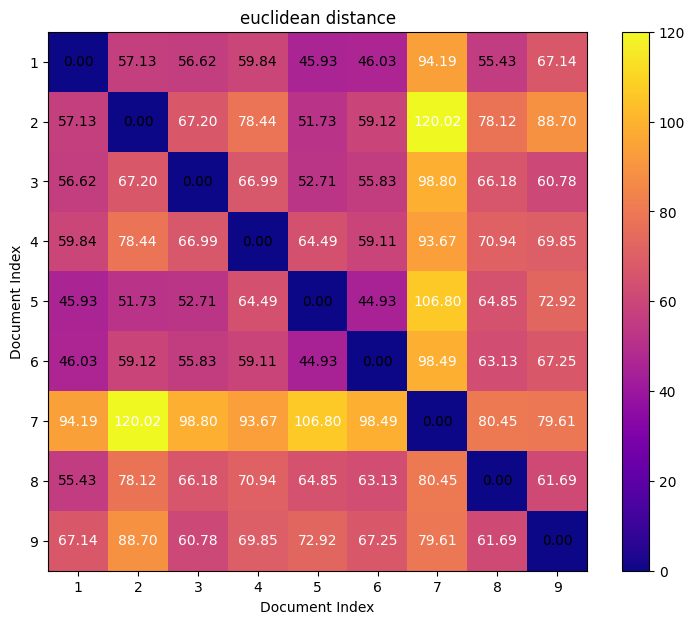

In [4]:
# 2. Euclidean Distance
def euclidean_distance(vec1, vec2):
    return np.linalg.norm(vec1 - vec2)

euclidean_matrix = np.zeros((len(documents), len(documents)))
for i in range(len(documents)):
    for j in range(len(documents)):
        euclidean_matrix[i, j] = euclidean_distance(term_doc_matrix[i], term_doc_matrix[j])
print("Euclidean Distance Matrix:")
print(euclidean_matrix)
plot_heatmap(euclidean_matrix,"euclidean distance")

Cosine Distance

Cosine Distance Matrix:
[[ 0.00000000e+00  5.04758978e-01  3.26005933e-01  2.93505928e-01
   3.23653043e-01  2.81138594e-01  2.07218128e-01  2.15796166e-01
   2.51134853e-01]
 [ 5.04758978e-01  2.22044605e-16  5.13321116e-01  5.84770603e-01
   5.37775994e-01  5.45340186e-01  5.30157712e-01  5.21860877e-01
   5.45106110e-01]
 [ 3.26005933e-01  5.13321116e-01 -2.22044605e-16  3.46062949e-01
   2.83571089e-01  3.17008977e-01  3.03232307e-01  3.16088661e-01
   2.07838428e-01]
 [ 2.93505928e-01  5.84770603e-01  3.46062949e-01 -2.22044605e-16
   3.49971946e-01  2.85194531e-01  2.71666527e-01  3.35682717e-01
   2.77116863e-01]
 [ 3.23653043e-01  5.37775994e-01  2.83571089e-01  3.49971946e-01
   0.00000000e+00  3.11192217e-01  3.01096370e-01  3.06185983e-01
   2.85336525e-01]
 [ 2.81138594e-01  5.45340186e-01  3.17008977e-01  2.85194531e-01
   3.11192217e-01  0.00000000e+00  2.55708199e-01  2.99664834e-01
   2.51755015e-01]
 [ 2.07218128e-01  5.30157712e-01  3.03232307e-01  2.71666527e-01
   3

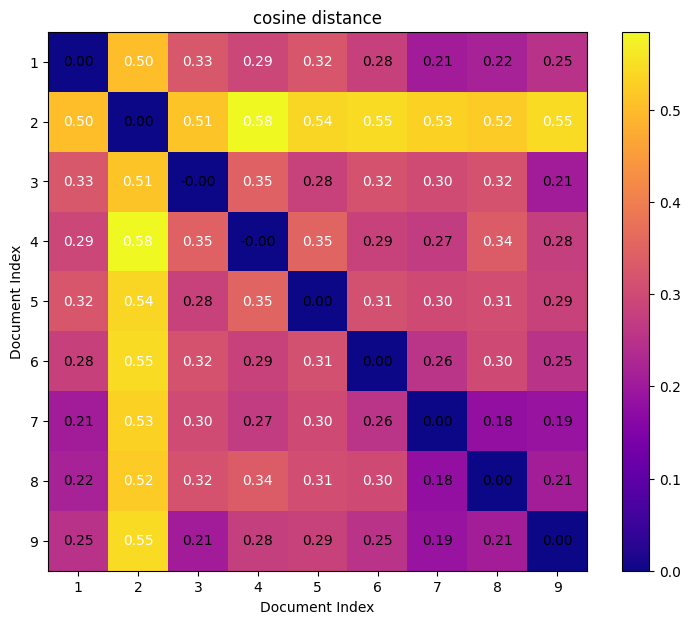

In [5]:
# 3. Cosine Distance
def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)

cosine_matrix = np.zeros((len(documents), len(documents)))
for i in range(len(documents)):
    for j in range(len(documents)):
        cosine_matrix[i, j] = 1 - cosine_similarity(term_doc_matrix[i], term_doc_matrix[j])
print("Cosine Distance Matrix:")
print(cosine_matrix)
plot_heatmap(cosine_matrix,"cosine distance")

K-L Divergence 

KL Divergence Matrix:
[[ 0.         11.26509072 10.35070901 10.42101381 11.54908906 10.89185059
   9.80629868 10.42440286 10.61869308]
 [11.48585641  0.         10.41101777 11.93415792 11.1365321  12.12768638
  11.19233121 11.42198727 11.0957921 ]
 [10.17689666  9.89252357  0.         11.31297519 10.70609257 10.38998972
   9.93763798  9.78022373  9.96211339]
 [10.26229663 11.58117601 11.14144165  0.         10.62801511  9.74832334
   9.53060966 10.54984163 10.33944097]
 [10.85829569 11.23371134 10.7183704  10.14164816  0.          9.98155547
   9.50748202  9.97023202 10.68444317]
 [11.11817145 11.61459305 10.67927878  9.57091047 11.07519819  0.
  10.36949771 10.7976702  10.54929541]
 [ 9.93623991 10.48223976 10.14074603  9.61580071 10.1458558   9.84284281
   0.          8.86167557  8.77845002]
 [10.45567516 10.77648055 10.25957515 10.68616944 10.4462456  10.69012398
   8.98028841  0.          9.72735499]
 [ 9.99773264 10.79307179 10.06486533 10.20595904 10.77387662 10.12753244
   8.312

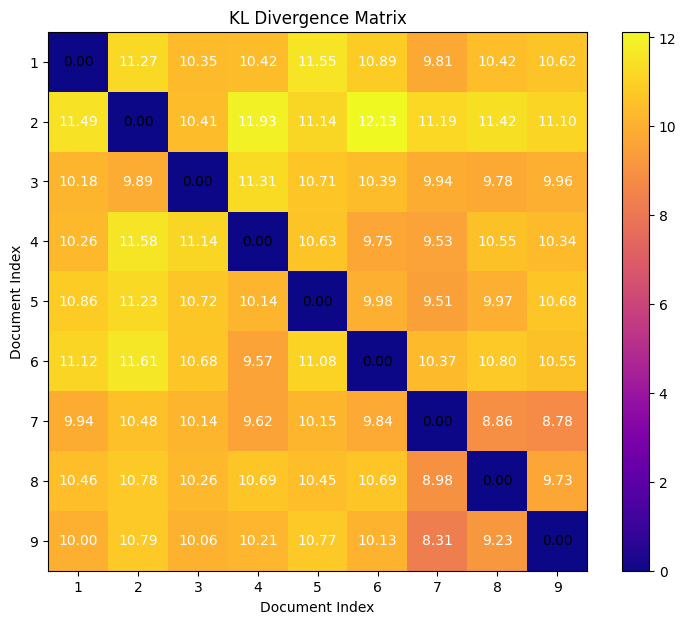

[ 632  440  732  821  436  609 1215  824  936]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.00136612 0.         0.00136612 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.00082305 0.00082305 0.00740741]
 [0.00121359 0.00121359 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [6]:
# 4. KL Divergence
def kl_divergence(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q))

row_sums = term_doc_matrix.sum(axis=1)  #  total terms in each document
prob_matrix = np.zeros_like(term_doc_matrix, dtype=float) # create a probability matrix
# it stores the normalized term frequencies
for i in range(len(term_doc_matrix)):
    if row_sums[i] > 0:
        prob_matrix[i] = term_doc_matrix[i] / row_sums[i]
    else:
        prob_matrix[i] = term_doc_matrix[i]

kl_matrix = np.zeros((len(documents), len(documents)))
for i in range(len(documents)):
    for j in range(len(documents)):
        kl_matrix[i, j] = kl_divergence(prob_matrix[i], prob_matrix[j])
print("KL Divergence Matrix:")
print(kl_matrix)
plot_heatmap(kl_matrix,"KL Divergence Matrix")
print(row_sums)
print(prob_matrix)

Question 2: Image Similarity Using Difference Images and Jaccard Distance

In [7]:
import cv2 
import numpy as np
image = cv2.imread('OR.jpg',cv2.IMREAD_GRAYSCALE)
array = np.array(image)
image2 = cv2.imread('GT.jpg',cv2.IMREAD_GRAYSCALE)
array2 = np.array(image2)
# calculate the absolute difference between OR and GT
diff = np.abs(array - array2)
print("Reference Difference |OR - GT|\n",diff,"\n")
# now binarizing the difference image
for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        if diff[i][j]>0:
            diff[i][j]=1
        else:
            diff[i][j]=0
print("Reference Difference |OR - GT| after binarizing\n",diff,"\n") # this is reference differnece image for jaccard distance
# this will be used to calculate jaccard distance considering this as reference

# creating the jacard distance function
def jaccard_distance(A,B):
    intersection = np.logical_and(A,B).sum()
    union = np.logical_or(A,B).sum()
    if(union == 0):
        return 0.0
    return 1-(intersection/union)
# now calculating the jaccard distance for all the algorithms
jaccard_distances = {}
for i in range(1,6):
    algo_img = cv2.imread(f'Algo{i}.jpg',cv2.IMREAD_GRAYSCALE)
    algo_array = np.array(algo_img)
    diff_algo = np.abs(array-algo_array)  # absolute difference with original
    for x in range(diff_algo.shape[0]):
        for y in range(diff_algo.shape[1]):
            if(diff_algo[x][y]>0):
                diff_algo[x][y] =1
            else:
                diff_algo[x][y] =0
    jaccard_dist = jaccard_distance(diff,diff_algo)
    jaccard_distances[f'Algo{i}'] = jaccard_dist
min_dis = 10000
for i in range(1,6):
    if( i ==1):
        print("Image File ------------ Jaccard Distance (less distance means more similar)")
    if(jaccard_distances[f"Algo{i}"]<min_dis):
        min_dis = jaccard_distances[f"Algo{i}"]
    print(f"Algo{i}.jpg -------------- {jaccard_distances[f'Algo{i}']}")
print(f"The best algorithm is Algo{list(jaccard_distances.values()).index(min_dis)+1} with jaccard distance of {min_dis}")



Reference Difference |OR - GT|
 [[  0   2   0 ... 254   0   0]
 [  0   1   1 ...   1   2   0]
 [  1   1   1 ... 255 255   0]
 ...
 [  0 254 255 ...   0   0   0]
 [  2   1   1 ...   3   2   0]
 [  1   0   0 ...   0   0   0]] 

Reference Difference |OR - GT| after binarizing
 [[0 1 0 ... 1 0 0]
 [0 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 0]
 ...
 [0 1 1 ... 0 0 0]
 [1 1 1 ... 1 1 0]
 [1 0 0 ... 0 0 0]] 

Image File ------------ Jaccard Distance (less distance means more similar)
Algo1.jpg -------------- 0.13933608302288447
Algo2.jpg -------------- 0.03661951859335677
Algo3.jpg -------------- 0.038619760266685565
Algo4.jpg -------------- 0.030316998794411743
Algo5.jpg -------------- 0.023147165003185366
The best algorithm is Algo5 with jaccard distance of 0.023147165003185366
